In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow import keras
import tensorflow as tf

from sklearn.decomposition import PCA

In [58]:
train_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_train.csv')
valid_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_valid.csv')
test_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_test.csv')

In [59]:
y_train = train_data2['full_price']
X_train = train_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

y_valid = valid_data2['full_price']
X_valid = valid_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

y_test = test_data2['full_price']
X_test = test_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

<Axes: >

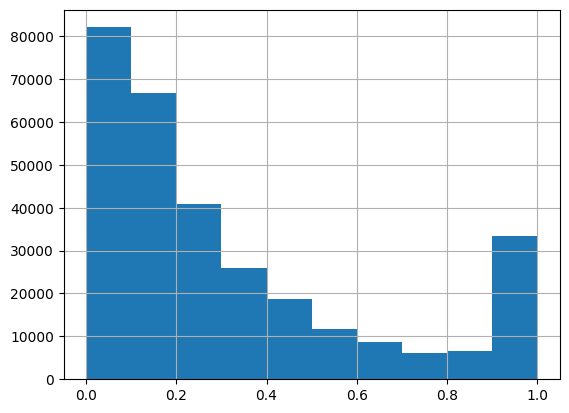

In [60]:
y_train.hist()

<Axes: >

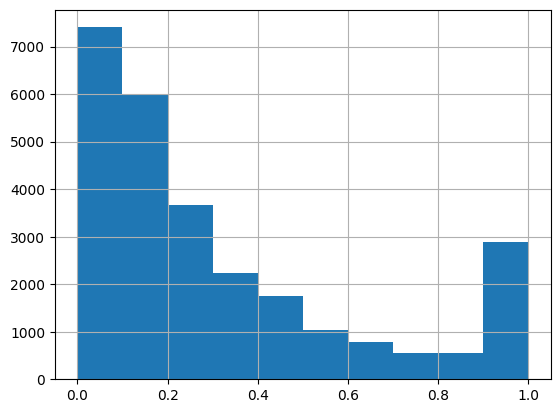

In [61]:
y_valid.hist()

In [62]:
X_train

,cat3_slug,land_size,building_size,deed_type,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,...,has_cooling_system_1,has_cooling_system_2,has_restroom_0,building_direction_0,building_direction_1,floor_material_0,floor_material_1,floor_material_2,floor_material_3,category_0
0,0.000000,1.000000,1.000000,1.0,0.064516,1.0,0.035714,0.125,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.111111,0.233184,0.247557,0.6,0.096774,0.2,0.071429,0.125,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.165919,0.208469,0.4,0.064516,0.4,0.035714,0.250,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.000000,0.446188,0.355049,1.0,0.322581,0.4,0.107143,0.125,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,0.111111,0.625561,0.908795,1.0,0.129032,0.8,0.142857,0.125,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301239,0.111111,0.446188,0.648208,0.4,0.129032,0.6,0.107143,0.125,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
301240,0.111111,0.334081,0.583062,0.4,0.096774,0.8,0.071429,0.125,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
301241,0.000000,0.221973,0.241042,0.4,0.096774,0.4,0.071429,0.375,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
301242,0.000000,0.179372,0.260586,1.0,0.064516,0.4,0.071429,0.125,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


# Modeling

## Method 1 (LinearRegression)

In [63]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=20)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.41
mse =	 0.13
mae =	 0.28


In [64]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=20)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.41
mse =	 0.13
mae =	 0.28


In [65]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=10)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.38
mse =	 0.13
mae =	 0.28


In [66]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.36
mse =	 0.12
mae =	 0.27


In [67]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=3)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.37
mse =	 0.13
mae =	 0.27


In [68]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=1)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.31
mse =	 0.12
mae =	 0.27


In [69]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=1)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.25
mse =	 0.11
mae =	 0.27


In [70]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)

model.fit(X_train1, y_train)
y_pred = model.predict(X_valid1)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.25
mse =	 0.11
mae =	 0.27


In [71]:
#PCA
pca = PCA(n_components=10)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)
y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.24
mse =	 0.11
mae =	 0.26


In [72]:
#PCA
pca = PCA(n_components=20)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.32
mse =	 0.12
mae =	 0.27


In [73]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.18
mse =	 0.11
mae =	 0.26


In [74]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.21
mse =	 0.11
mae =	 0.26


In [75]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

model = LinearRegression(positive=True)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.11
mse =	 0.1
mae =	 0.25


In [76]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.03
mse =	 0.1
mae =	 0.25


In [77]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.04
mse =	 0.1
mae =	 0.25


## Method 2 (Ridge)

In [78]:
model = Ridge(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)

model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.18
mse =	 0.11
mae =	 0.26


In [79]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.03
mse =	 0.1
mae =	 0.25


In [80]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(alpha=0.1, positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.03
mse =	 0.1
mae =	 0.25


In [81]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(alpha=10, positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.03
mse =	 0.1
mae =	 0.25


In [82]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.21
mse =	 0.11
mae =	 0.26


In [83]:
y_pred = model.predict(X_test2)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.22
mse =	 0.11
mae =	 0.26


## Method 3 (Lasso)

In [84]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [85]:
y_pred

array([0.3235261, 0.3235261, 0.3235261, ..., 0.3235261, 0.3235261,
       0.3235261], shape=(26835,))

In [86]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [87]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [88]:
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [89]:
model = Lasso(alpha=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [90]:
model = Lasso(alpha=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [91]:
poly_transformer = PolynomialFeatures(degree=2)

X_train1 = poly_transformer.fit_transform(X_train)
X_valid1 = poly_transformer.transform(X_valid)
X_test1 = poly_transformer.transform(X_test)

model = Lasso(alpha=0.1)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [92]:
y_pred

array([0.3235261, 0.3235261, 0.3235261, ..., 0.3235261, 0.3235261,
       0.3235261], shape=(26835,))

## Method 4 (SVR)

In [93]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.87
mse =	 0.17
mae =	 0.34


In [94]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.31
mse =	 0.12
mae =	 0.32


In [95]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)


model = SVR(C=1.0, max_iter=1000)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.35
mse =	 0.12
mae =	 0.32


In [96]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)


model = SVR(C=0.1, max_iter=1000)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.35
mse =	 0.12
mae =	 0.32


In [97]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.26
mse =	 0.12
mae =	 0.31


In [98]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.32
mse =	 0.12
mae =	 0.31


## Method 5 (DecisionTreeRegressor)

In [99]:
model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [100]:
model = grid.best_estimator_
y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.75
mse =	 0.16
mae =	 0.3


In [101]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train1, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [102]:
model = grid.best_estimator_
y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.48
mse =	 0.14
mae =	 0.28


In [103]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train2, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [104]:
model = grid.best_estimator_
y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.45
mse =	 0.13
mae =	 0.28


In [105]:
y_pred = model.predict(X_test2)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.4
mse =	 0.13
mae =	 0.28


## Method 6 (Boosting)

## Method 7 (Shallow neural networks)

In [106]:
X_train.shape

(301244, 34)

In [116]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

In [127]:
# define model
model = keras.Sequential()
model.add(keras.layers.Input(X_train1.shape[1:]))
model.add(keras.layers.Dense(units=128, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=1))

model.summary()

# compile model
model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=0.01) , metrics=['mse', 'mae', 'r2_score'])

# train model
history = model.fit(X_train1, y_train,
                    batch_size=32,
                    epochs=20,
                    validation_data=(X_valid1, y_valid),
                    shuffle=True)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
9414/9414 ━━━━━━━━━━━━━━━━━━━━ 8s 764us/step - loss: 0.0727 - mae: 0.2053 - mse: 0.0727 - r2_score: 0.2235 - val_loss: 0.1093 - val_mae: 0.2562 - val_mse: 0.1093 - val_r2_score: -0.1853
Epoch 2/20
9414/9414 ━━━━━━━━━━━━━━━━━━━━ 7s 756us/step - loss: 0.0723 - mae: 0.2048 - mse: 0.0723 - r2_score: 0.2276 - val_loss: 0.1116 - val_mae: 0.2615 - val_mse: 0.1116 - val_r2_score: -0.2106
Epoch 3/20
9414/9414 ━━━━━━━━━━━━━━━━━━━━ 7s 729us/step - loss: 0.0722 - mae: 0.2047 - mse: 0.0722 - r2_score: 0.2282 - val_loss: 0.1220 - val_mae: 0.2733 - val_mse: 0.1220 - val_r2_score: -0.3234
Epoch 4/20
9414/9414 ━━━━━━━━━━━━━━━━━━━━ 7s 728us/step - loss: 0.0723 - mae: 0.2049 - mse: 0.0723 - r2_score: 0.2273 - val_loss: 0.1064 - val_mae: 0.2549 - val_mse: 0.1064 - val_r2_score: -0.1540
Epoch 5/20
9414/9414 ━━━━━━━━━━━━━━━━━━━━ 7s 728us/step - loss: 0.0722 - mae: 0.2048 - mse: 0.0722 - r2_score: 0.2284 - val_loss: 0.1143 - val_mae: 0.2628 - val_mse: 0.1143 - val_r2_score: -0.2397
Epoch 6/20
9414

In [128]:
y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

839/839 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step
r2 =	 -0.16
mse =	 0.11
mae =	 0.25


In [129]:
y_pred = model.predict(X_test1)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step
r2 =	 -0.15
mse =	 0.11
mae =	 0.26


In [130]:
y_test

0        0.026820
1        0.034483
2        0.229885
3        1.000000
4        0.375479
           ...   
11778    0.122605
11779    0.101916
11780    0.122605
11781    0.203065
11782    0.176245
Name: full_price, Length: 11783, dtype: float64

In [131]:
y_pred

array([[0.7790727 ],
       [0.28705883],
       [0.28819156],
       ...,
       [0.8644222 ],
       [0.24215882],
       [0.3542952 ]], shape=(11783, 1), dtype=float32)